
# 🚀 Gradient Boosting

Aquest notebook mostra un exemple d'us del Model **Gradient Boosting**. Una de les estratègies d'*Ensemble Models*. En aquest cas s'utlitza la tècnica **Boosting**

---

## 🎯 Objectius
- Veure el pas a pas de com s'implementa un Gradient Boosting
- Com utilitzar un Gradient Boosting de Scikit-Leran


##  👣 Pas a pas de com s'implementa el Gradient Boosting


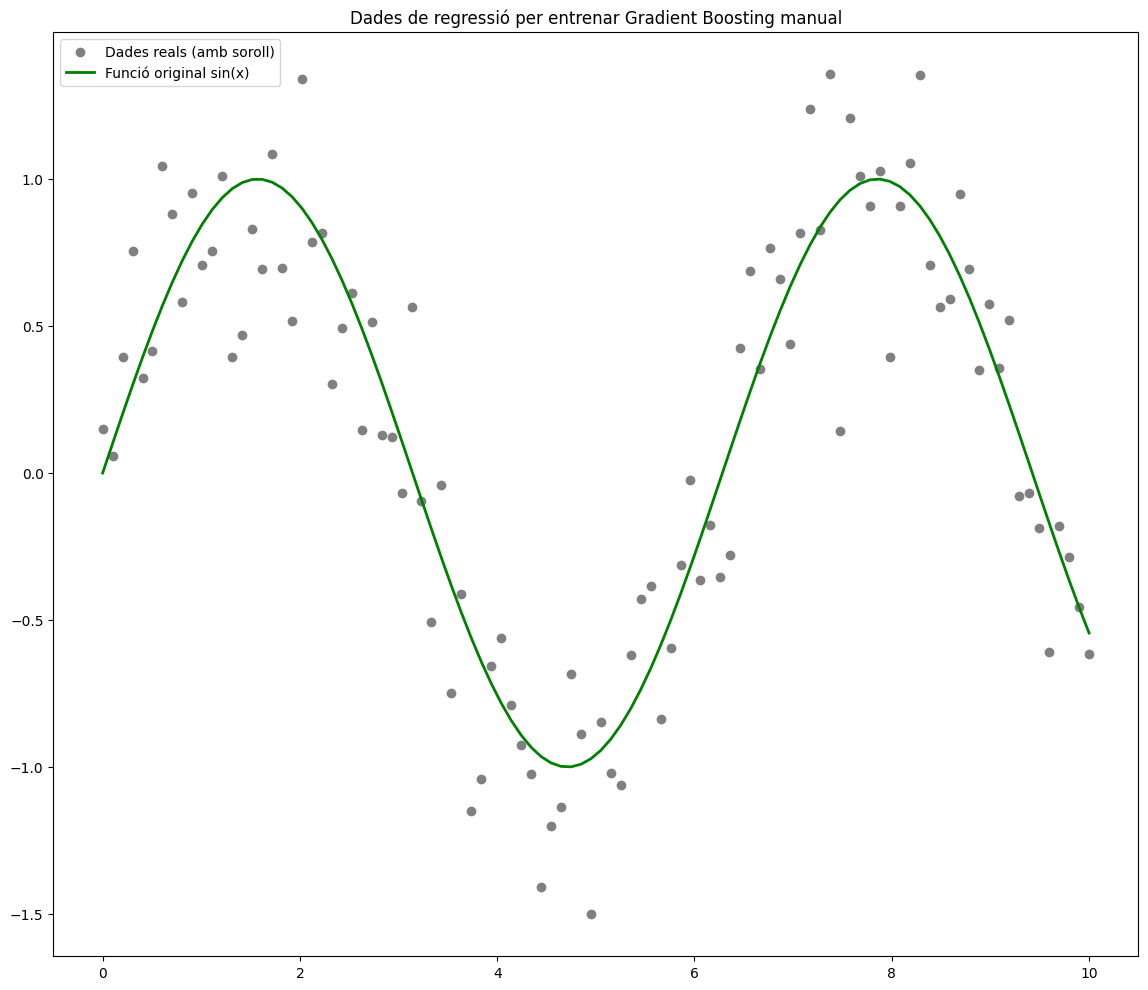

Iteració 1/20 — MSE: 0.4547
Iteració 2/20 — MSE: 0.4076
Iteració 3/20 — MSE: 0.3626
Iteració 4/20 — MSE: 0.3254
Iteració 5/20 — MSE: 0.2951
Iteració 6/20 — MSE: 0.2690
Iteració 7/20 — MSE: 0.2509
Iteració 8/20 — MSE: 0.2303
Iteració 9/20 — MSE: 0.2161
Iteració 10/20 — MSE: 0.1996
Iteració 11/20 — MSE: 0.1885
Iteració 12/20 — MSE: 0.1738
Iteració 13/20 — MSE: 0.1648
Iteració 14/20 — MSE: 0.1530
Iteració 15/20 — MSE: 0.1430
Iteració 16/20 — MSE: 0.1361
Iteració 17/20 — MSE: 0.1279
Iteració 18/20 — MSE: 0.1222
Iteració 19/20 — MSE: 0.1165
Iteració 20/20 — MSE: 0.1120


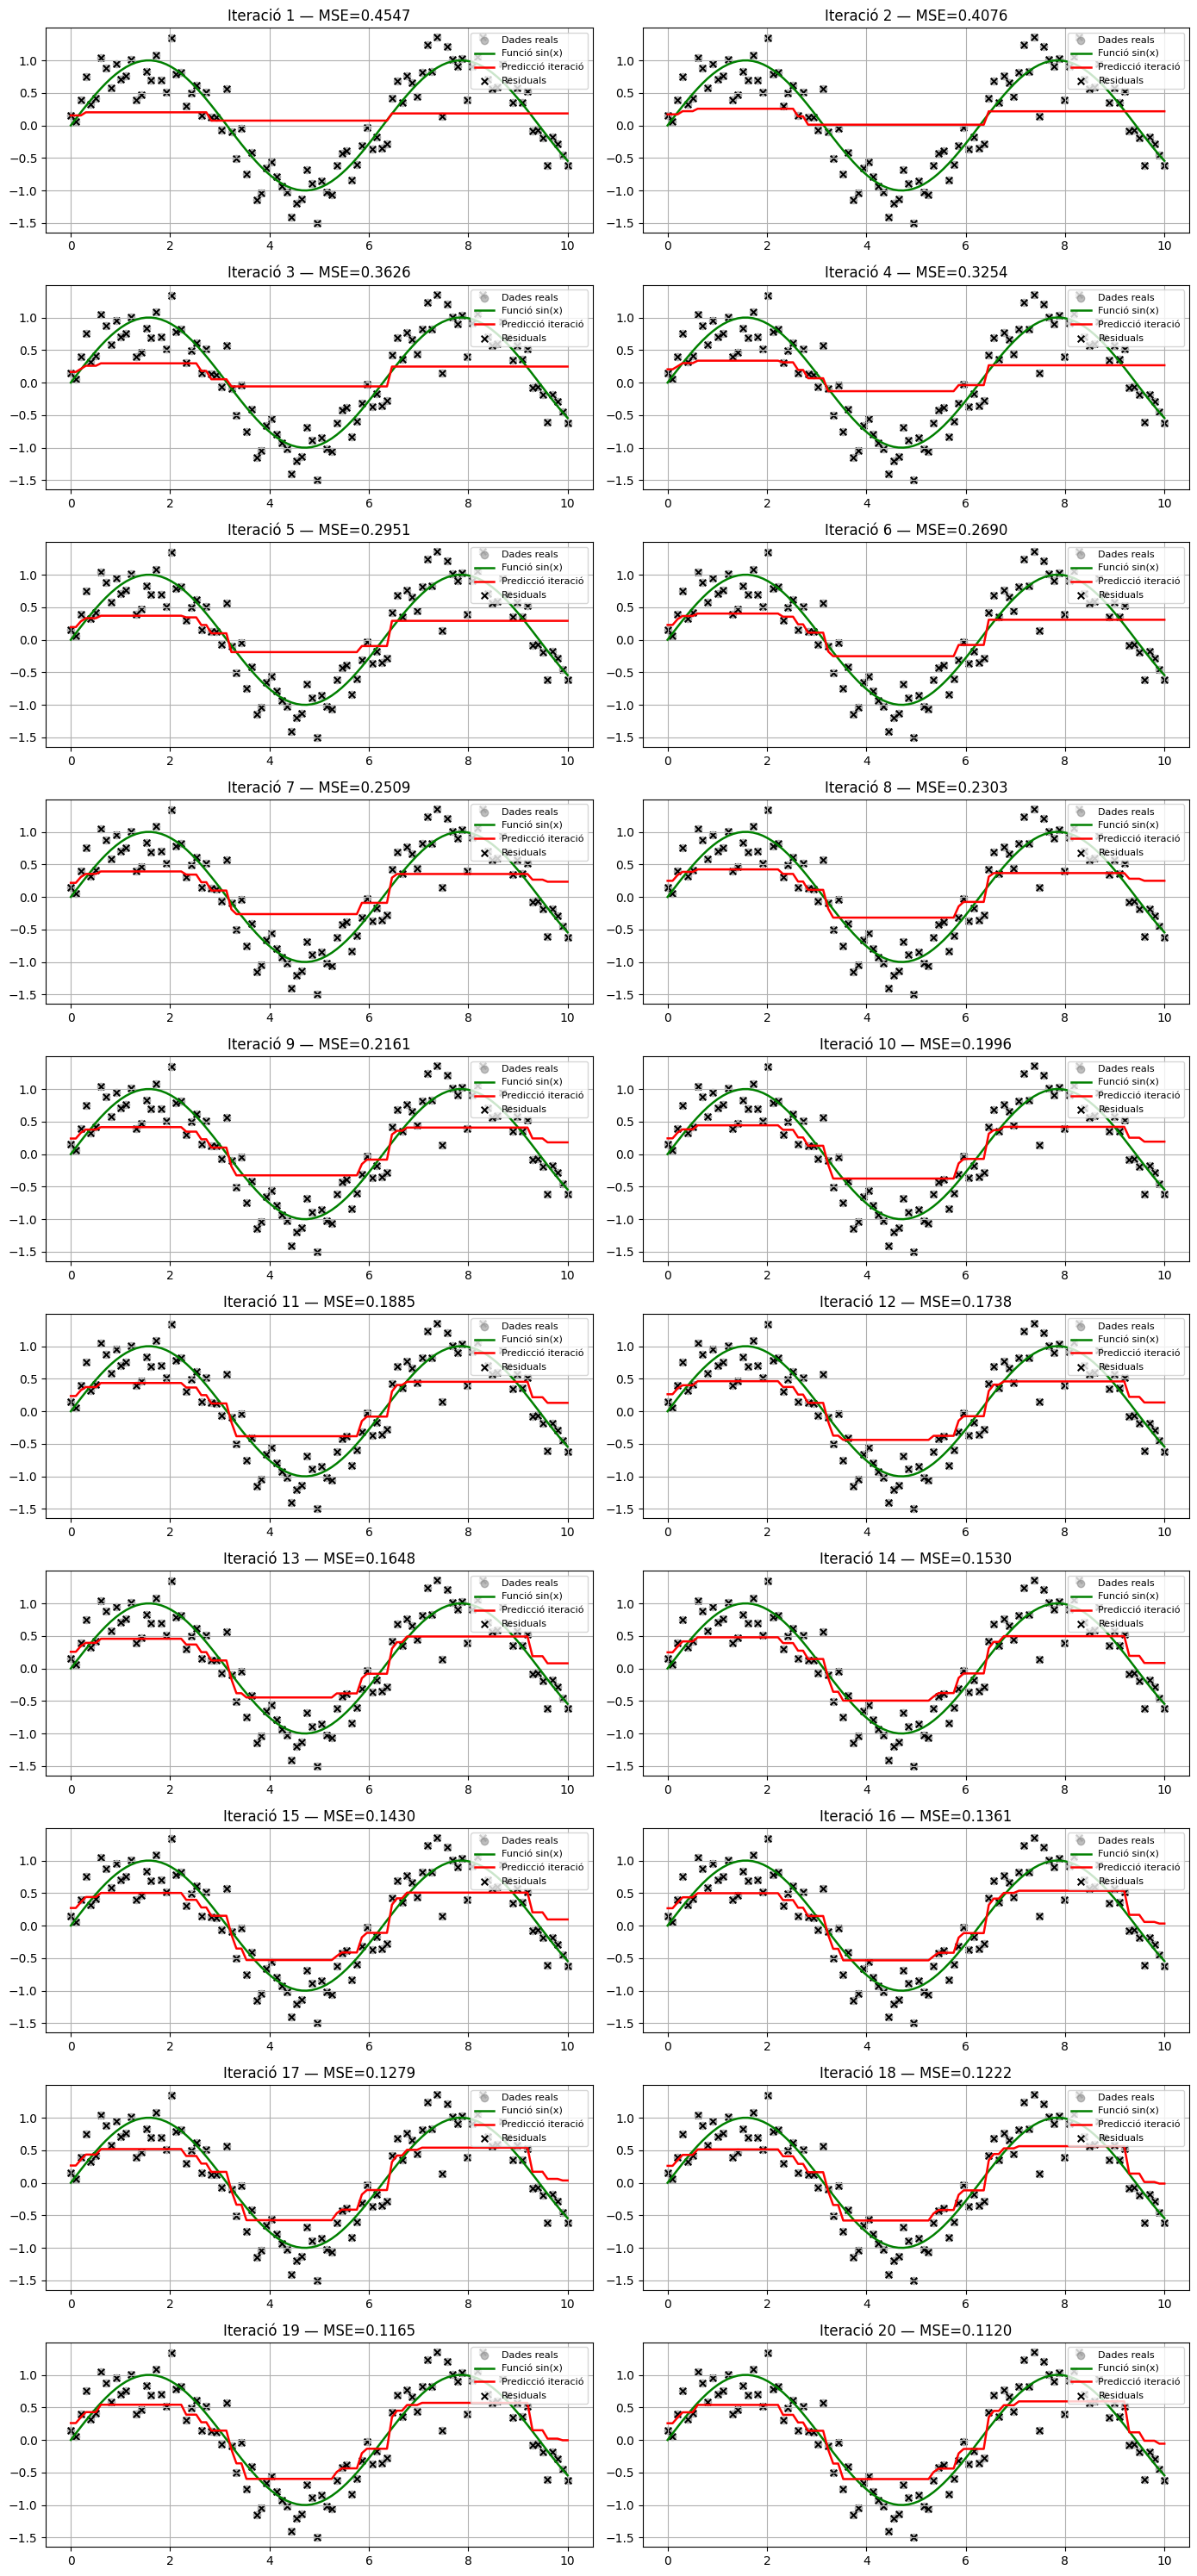

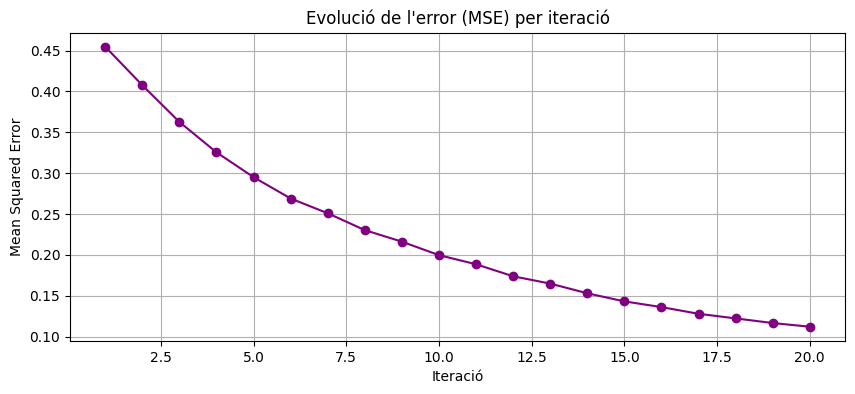


Prediccions per a nous valors:
   X = 1.50 → Predicció y = 0.539
   X = 4.00 → Predicció y = -0.601
   X = 7.80 → Predicció y = 0.593
   X = 9.50 → Predicció y = 0.117


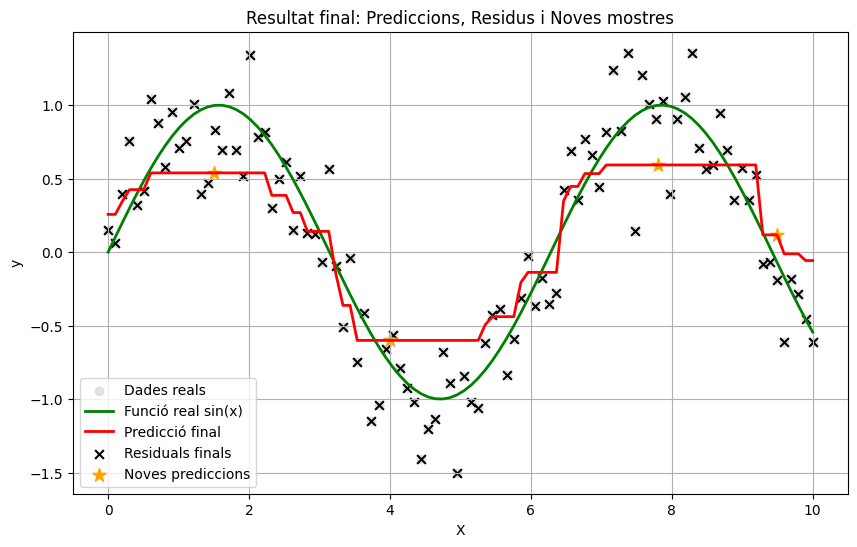

In [11]:
# ================================================================
# 🌳 Comprendre el Gradient Boosting pas a pas amb Decision Trees
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Configuració gràfica
plt.rcParams["figure.figsize"] = (14, 12)
np.random.seed(42)

# ================================================================
# 1️⃣ Generació de dades sintètiques
# ================================================================

X = np.linspace(0, 10, 100).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(0, 0.3, size=len(X))

plt.scatter(X, y, color="gray", label="Dades reals (amb soroll)")
plt.plot(X, y_true, color="green", linewidth=2, label="Funció original sin(x)")
plt.title("Dades de regressió per entrenar Gradient Boosting manual")
plt.legend()
plt.show()

# ================================================================
# 2️⃣ Inicialització del model
# ================================================================

F0 = np.mean(y)
y_pred = np.full_like(y, fill_value=F0, dtype=float)

n_estimators = 20
learning_rate = 0.1
max_depth = 2

trees = []
train_errors = []

# ================================================================
# 3️⃣ Entrenament iteratiu i emmagatzematge de resultats per visualitzar
# ================================================================

preds_per_iter = []  # per guardar les prediccions després de cada iteració

for m in range(n_estimators):
    residuals = y - y_pred
    tree = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    tree.fit(X, residuals)

    y_pred += learning_rate * tree.predict(X)
    mse = mean_squared_error(y, y_pred)

    trees.append(tree)
    train_errors.append(mse)
    preds_per_iter.append(y_pred.copy())

    print(f"Iteració {m+1}/{n_estimators} — MSE: {mse:.4f}")

# ================================================================
# 4️⃣ Visualització en graella del procés iteratiu
# ================================================================

rows = n_estimators // 2 + n_estimators % 2  # 2 columnes
fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 3))
axes = axes.flatten()

for i, ax in enumerate(axes[:n_estimators]):
    y_pred_i = preds_per_iter[i]
    residuals_i = y - y_pred_i

    ax.scatter(X, y, color="gray", alpha=0.5, label="Dades reals")
    ax.plot(X, y_true, color="green", linewidth=1.8, label="Funció sin(x)")
    ax.plot(X, y_pred_i, color="red", linewidth=1.8, label="Predicció iteració")

    # Residus com a creus negres
    ax.scatter(X, y_pred_i + residuals_i, color="black", marker="x", s=30, label="Residuals")

    ax.set_title(f"Iteració {i+1} — MSE={train_errors[i]:.4f}")
    ax.grid(True)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

# ================================================================
# 5️⃣ Evolució de l'error
# ================================================================

plt.figure(figsize=(10, 4))
plt.plot(range(1, n_estimators+1), train_errors, marker='o', color="purple")
plt.title("Evolució de l'error (MSE) per iteració")
plt.xlabel("Iteració")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

# ================================================================
# 6️⃣ Predicció per a nous valors
# ================================================================

X_new = np.array([[1.5], [4.0], [7.8], [9.5]])
y_pred_new = np.full(shape=X_new.shape[0], fill_value=F0)

for tree in trees:
    y_pred_new += learning_rate * tree.predict(X_new)

print("\nPrediccions per a nous valors:")
for x_val, y_val in zip(X_new.ravel(), y_pred_new):
    print(f"   X = {x_val:.2f} → Predicció y = {y_val:.3f}")

# ================================================================
# 7️⃣ Visualització final amb residus i noves prediccions
# ================================================================

residuals_final = y - preds_per_iter[-1]

plt.figure(figsize=(10,6))
plt.scatter(X, y, color="lightgray", alpha=0.6, label="Dades reals")
plt.plot(X, y_true, color="green", linewidth=2, label="Funció real sin(x)")
plt.plot(X, preds_per_iter[-1], color="red", linewidth=2, label="Predicció final")
plt.scatter(X, preds_per_iter[-1] + residuals_final, color="black", marker="x", s=40, label="Residuals finals")
plt.scatter(X_new, y_pred_new, color="orange", s=100, marker="*", label="Noves prediccions")
plt.title("Resultat final: Prediccions, Residus i Noves mostres")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


##  🏠 Exemple Gradient Boosting - Boston Housing

Volem predir la variable MEDV. valor mijtà de les vivendes.

En el conjunt de dades tenim:
- **CRIM**: taxa de delinqüència per càpita per ciutat.
- **ZN**: proporció de sòl residencial dividit per a segments de més de 25.000 peus quadrats.
- **INDUS**: proporció de superfície comercial no minorista per ciutat.
- **CHAS**: variable binària sobre el riu Charles (= 1 si la zona limita amb el riu; 0 en cas contrari).
- **NOX**: concentració d'òxids nítrics (parts de 10 milions).
- **RM**: nombre mitjà d'habitacions per habitatge.
- **EDAT**: proporció d'habitatges ocupats construïts abans del 1940.
- **DIS**: distància ponderada a cinc centres de treball a la ciutat de Boston.
- **RAD**: índex daccessibilitat a les autopistes radials.
- **TAX**: impost sobre béns immobles de valor íntegre per cada 10.000 dólars
- **PTRATIO**: ràtio alumnes-professor per ciutat.
- **LSTAT**: % de la població considerat de classe baixa.
- **MEDV** (variable a predir): valor mitjà dels habitatges en milers de $.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score



# Load the Boston Housing dataset
boston = fetch_openml(name='boston')

df = boston['data']
df['MEDV'] = boston['target']
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


###  Exemple d'ús Gradient Boosting

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

# Dividim el conjunt de dades train/test
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns="MEDV"),
                                        df['MEDV'],
                                        test_size = 0.25,
                                        random_state = 123
                                    )

print(f"Train: {X_train.shape[0]} observacions")
print(f"Test: {X_test.shape[0]} observacions")


# Creem el model
# max_depth:
# n_estimators: Número d'arbres que s'utilitzarà en el model
# learning_rate=1.0
model_gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0,random_state = 54)

model_gbrt.fit(X_train, y_train)

# Avaluem el model
# ==============================================================================
y_pred = model_gbrt.predict(X=X_test)

rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
print(f"El error (rmse) de test es: {rmse}")

r2= r2_score(y_true=y_test, y_pred=y_pred)
print(f"El error (r2) de test es: {r2}")

Train: 379 observacions
Test: 127 observacions
El error (rmse) de test es: 5.233658020449947
El error (r2) de test es: 0.6530225529700417


### Exemple d'ús Gradient Boosting - `n_iter_no_change`

Utlitzem aquest parèmtre per no haver d'utilizar `GridSerchCV` o `RandomizedSearchCV`
Aques hiperparèmtre fa d'early stopping per aturar l'entrenament quan els últims X arbres afegits no han millorat el rendiment.

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

# Dividim el conjunt de dades train/test
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns="MEDV"),
                                        df['MEDV'],
                                        test_size = 0.25,
                                        random_state = 123
                                    )

print(f"Train: {X_train.shape[0]} observacions")
print(f"Test: {X_test.shape[0]} observacions")


# Creem el model
# max_depth:
# n_estimators: Número d'arbres que s'utilitzarà en el model
# learning_rate=1.0
model_gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=500,
                                       n_iter_no_change=5,
                                      validation_fraction=0.1,
                                      learning_rate=0.05,random_state = 54)

model_gbrt.fit(X_train, y_train)

print(f"El vlor n_estimators trobat: {model_gbrt.n_estimators_}")
# Avaluem el model
# ==============================================================================
y_pred = model_gbrt.predict(X=X_test)

rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
print(f"El error (rmse) de test es: {rmse}")

r2= r2_score(y_true=y_test, y_pred=y_pred)
print(f"El error (r2) de test es: {r2}")


Train: 379 observacions
Test: 127 observacions
El vlor n_estimators trobat: 107
El error (rmse) de test es: 3.477731991476487
El error (r2) de test es: 0.846791526568939
